In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

project_folder = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

df = pd.read_csv(project_folder / "data" / "clean" / "mahtab_clean.csv")

print(df.shape)
df.head()

(14063, 3)


,row_id,bmipct,sleep_hours
0,1,97.08,3.0
1,3,92.26,1.0
2,5,7.57,3.0
3,6,68.89,2.0
4,7,60.48,2.0


In [5]:
df[["sleep_hours", "bmipct"]].corr()

,sleep_hours,bmipct
sleep_hours,1.000000,-0.020445
bmipct,-0.020445,1.000000


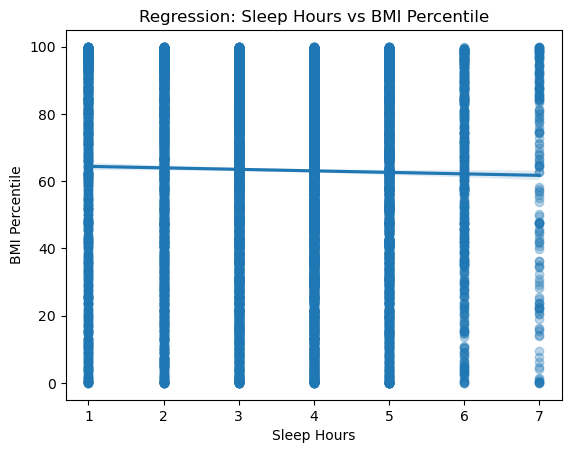

In [6]:
sns.regplot(x="sleep_hours", y="bmipct", data=df, scatter_kws={"alpha":0.3})
plt.title("Regression: Sleep Hours vs BMI Percentile")
plt.xlabel("Sleep Hours")
plt.ylabel("BMI Percentile")
plt.show()

In [7]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["sleep_hours"], df["bmipct"])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.02044480789214993
P-value: 0.015327923336995867


In [8]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = df[["sleep_hours"]]
y = df["bmipct"]

model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: -0.44665950358195694
Intercept: 64.8742273841761


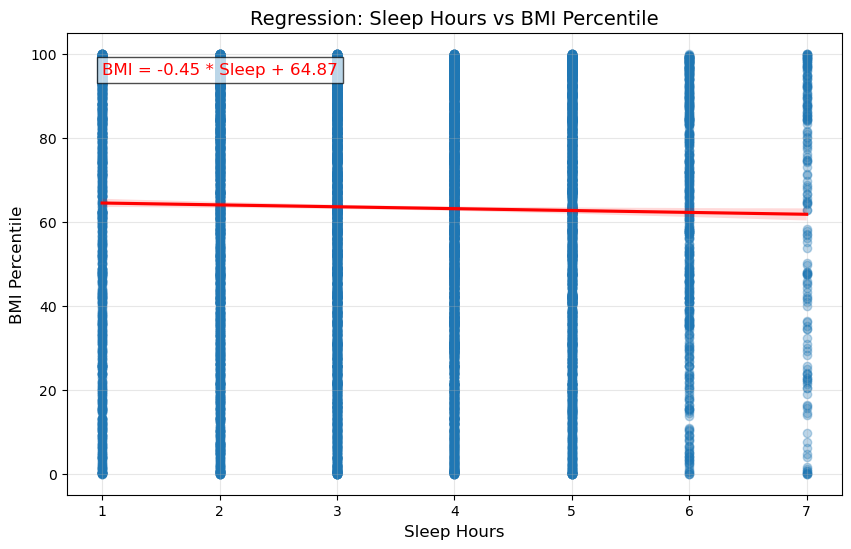

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Scatter + regression line
sns.regplot(
    x="sleep_hours",
    y="bmipct",
    data=df,
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

# Lägg till titel och labels
plt.title("Regression: Sleep Hours vs BMI Percentile", fontsize=14)
plt.xlabel("Sleep Hours", fontsize=12)
plt.ylabel("BMI Percentile", fontsize=12)

# 🔥 Lägg till ekvation i grafen
plt.text(
    1, 95,  # position (justera om du vill)
    "BMI = -0.45 * Sleep + 64.87",
    fontsize=12,
    color="red",
    bbox=dict(facecolor="white", alpha=0.7)
)

plt.grid(alpha=0.3)
plt.show()